# 05. Frozen model comparison, explainability and robustness

```text
venv\Scripts\python.exe -m pip install numpy pandas matplotlib pillow scikit-learn scikit-image joblib torch==2.14.0 torchvision==0.29.0 captum==0.9.0
```

Run from the project root using its existing virtual environment. The command above is the requested installation command, not an instruction to change an already working environment. Actual versions are recorded below. No model is fitted, calibrated or retuned in this notebook.

**Research question:** To what extent does learned representation improve six-class steel-surface defect classification over fixed HOG features, and how does that comparison change under image-condition stress and practical computation constraints?

This is the authorised final evaluation of the frozen models from notebooks 03 and 04, with the epoch decision verified against 04a. Both models receive the same 360 locked test images. Development contains 1,439 images and one duplicate remains excluded. Results apply to classification among six known defect categories. There is no normal or defect-free class.

**Evaluation boundary.** All modelling choices are frozen. Thresholds for diagnostic subgroups come from development images only. Perturbations, example-selection rules and reporting conventions are declared before test decoding. Reruns reuse integrity-checked saved clean predictions; they do not initiate another main evaluation. Stress tests, attribution and timing are separate analyses of the frozen models. Nothing observed here authorises model selection. A future changed model would require a new evaluation plan and independent data.

**Evidence limitations inherited from the project.** Descriptive EDA included the full collection before the split. This is therefore a model-selection holdout, not prospectively untouched external validation. Image-level splitting and exact duplicate removal do not establish independence of near-duplicates or acquisition groups. The local files match the retained Figshare archive, whose size and MD5 match the published metadata. Equivalence to the separately hosted original university archive remains unverified; see data/NEU-CLS/Dataset-Information.txt. The original assignment brief is available in the wider assignment context and governs final submission coverage alongside the recorded methodology.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from importlib.metadata import version
import hashlib, json, os, platform, sys, subprocess, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from IPython.display import display, Markdown
import joblib
import torch
from torch import nn
from captum.attr import LayerGradCam, LayerAttribution
from skimage.feature import hog
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from threadpoolctl import threadpool_limits, threadpool_info

ROOT = Path.cwd().resolve()
assert (ROOT/'03_classical_hog_svm.ipynb').is_file(), 'Run from the project root.'
RUN = ROOT/'outputs/experiments/05_comparison_xai_robustness'
RUN.mkdir(parents=True, exist_ok=True)
for folder in ['tables','figures','reports','reproducibility','cache']:
    (RUN/folder).mkdir(exist_ok=True)
def sha(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()
def readj(p): return json.loads(Path(p).read_text(encoding='utf-8'))
def writej(p, value):
    p=Path(p); tmp=p.with_suffix(p.suffix+'.tmp')
    tmp.write_text(json.dumps(value, indent=2, allow_nan=False), encoding='utf-8'); tmp.replace(p)
CHECKS=[]
def check(name, value):
    CHECKS.append({'check':name, 'status':'PASS' if bool(value) else 'FAIL'})
    pd.DataFrame(CHECKS).to_csv(RUN/'reports/acceptance_checks.csv',index=False)
    if not bool(value): raise RuntimeError(name)
def table(frame, name, show=True, index=False):
    frame.to_csv(RUN/'tables'/f'{name}.csv',index=index)
    if show: display(frame)
def figure(fig, name):
    fig.savefig(RUN/'figures'/f'{name}.png',dpi=150,facecolor='white',bbox_inches='tight')
    plt.show(); plt.close(fig)
NARRATIVE=[]
def interpret(text):
    NARRATIVE.append(text); display(Markdown(text))
torch.set_num_threads(4)
torch.use_deterministic_algorithms(True)
torch.manual_seed(42); np.random.seed(42)
pool_limit=threadpool_limits(limits=4)
environment={'utc':datetime.now(timezone.utc).isoformat(),'python':sys.version,'executable':sys.executable,
    'platform':platform.platform(),'processor':platform.processor(),'logical_cpus':os.cpu_count(),
    'device':'cpu','torch_threads':torch.get_num_threads(),'threadpools':threadpool_info(),
    'packages':{p:version(p) for p in ['numpy','pandas','matplotlib','pillow','scikit-learn','scikit-image','joblib','torch','torchvision','captum','nbformat','nbclient']}}
writej(RUN/'reproducibility/environment.json',environment)
(RUN/'reproducibility/pip_freeze.txt').write_text(subprocess.check_output([sys.executable,'-m','pip','freeze'],text=True),encoding='utf-8')
print(json.dumps(environment,indent=2))

{
  "utc": "2026-09-27T01:47:36.940222+00:00",
  "python": "3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]",
  "executable": "C:\\Scripts\\industrial-defect-intelligence\\venv\\Scripts\\python.exe",
  "platform": "Windows-11-10.0.26200-SP0",
  "processor": "Intel64 Family 6 Model 186 Stepping 3, GenuineIntel",
  "logical_cpus": 12,
  "device": "cpu",
  "torch_threads": 4,
  "threadpools": [
    {
      "user_api": "blas",
      "internal_api": "openblas",
      "num_threads": 4,
      "prefix": "libscipy_openblas",
      "filepath": "C:\\Scripts\\industrial-defect-intelligence\\venv\\Lib\\site-packages\\numpy.libs\\libscipy_openblas64_-ed4f167a5330424524f45258e7ca2c8d.dll",
      "version": "0.3.34.106.0",
      "threading_layer": "pthreads",
      "architecture": "Haswell"
    },
    {
      "user_api": "openmp",
      "internal_api": "openmp",
      "num_threads": 4,
      "prefix": "libiomp",
      "filepath": "C:\\Scripts\\industrial-defect-intelli

## 1. Verify the evidence chain before test access

The latest pointers are checked against their result hashes. Model files are located by matching the recorded digest, rather than by assuming a checkpoint name. The split, shared folds, preparation status, model configuration, class order, normalisation and epoch decision must all agree. SHA-256 proves consistency with these local records, not external provenance. Earlier development records must explicitly report no test evaluation.

In [2]:
source_paths={
    'manifest':ROOT/'outputs/metrics/data_split_manifest.csv',
    'split_lock':ROOT/'outputs/metrics/split_lock.json',
    'folds':ROOT/'outputs/metrics/development_cv_folds.csv',
    'fold_lock':ROOT/'outputs/metrics/development_cv_lock.json',
    'split_status':ROOT/'outputs/reports/02_split_status.json',
    'fold_status':ROOT/'outputs/reports/02a_validation_status.json'}
sources={k:sha(v) for k,v in source_paths.items()}
records={}; runs={}
for key, pointer_name in [('svm','03_classical_latest.json'),('cnn','04_cnn_latest.json'),('sensitivity','04a_cnn_epoch_sensitivity_latest.json')]:
    pointer_path=ROOT/'outputs/reports'/pointer_name
    pointer=readj(pointer_path); run=(ROOT/pointer['run_directory']).resolve()
    check(key+' pointer inside project outputs',run.is_relative_to(ROOT/'outputs'))
    check(key+' result digest',sha(run/'result.json')==pointer['result_sha256'])
    result=readj(run/'result.json')
    check(key+' passed without test evaluation',pointer['status']==result['status']=='PASS' and result['test_evaluation_performed'] is False and result['test_images_opened']==0)
    for k,v in sources.items():
        check(key+' source '+k,result.get('source_digests',result.get('source_hashes'))[k]==v)
    records[key]=result; runs[key]=run
    source_paths[key+'_pointer']=pointer_path
    source_paths[key+'_result']=run/'result.json'
    source_paths[key+'_protocol']=run/'protocol.json'
lock=readj(source_paths['split_lock']); fold_lock=readj(source_paths['fold_lock'])
CLASSES=lock['classes']; LABELS=np.arange(len(CLASSES))
check('Six expected classes',CLASSES==['crazing','inclusion','patches','pitted_surface','rolled_in_scale','scratches'])
check('Locked manifest digest',sources['manifest']==lock['manifest_sha256']==fold_lock['split_manifest_sha256'])
check('Locked fold digest',sources['folds']==fold_lock['folds_sha256'])
check('Preparation passed',readj(source_paths['split_status'])['status']==readj(source_paths['fold_status'])['status']=='PASS')
manifest=pd.read_csv(source_paths['manifest'],keep_default_na=False)
dev=manifest.loc[manifest.split.eq('development')].sort_values('path').reset_index(drop=True)
test=manifest.loc[manifest.split.eq('test')].sort_values('path').reset_index(drop=True)
excluded=manifest.loc[~manifest.split.isin(['development','test'])]
check('Counts 1439 / 360 / 1',len(manifest)==1800 and len(dev)==1439 and len(test)==360 and len(excluded)==1)
check('Unique paths and modelling flags',manifest.path.is_unique and dev.include_in_modelling.all() and test.include_in_modelling.all() and not excluded.include_in_modelling.any())
for key in ['path','sha256','pixel_sha256']:
    check('Disjoint and unique retained '+key,dev[key].is_unique and test[key].is_unique and not set(dev[key])&set(test[key]))
check('Excluded record duplicates a retained image',excluded.sha256.iloc[0] in set(pd.concat([dev,test]).sha256))
folds=pd.read_csv(source_paths['folds'])
check('Shared folds cover development only',folds.path.is_unique and set(folds.path)==set(dev.path))
for col in ['class_name','sha256','pixel_sha256']:
    check('Fold metadata '+col,folds.set_index('path').loc[dev.path,col].tolist()==dev[col].tolist())
check('Test contains 60 images per class',test.class_name.value_counts().reindex(CLASSES).eq(60).all())
def locate_digest(directory, suffix, expected):
    found=[p for p in directory.rglob('*'+suffix) if sha(p)==expected]
    check('Exactly one matching '+suffix+' artefact',len(found)==1)
    return found[0]
svm_path=locate_digest(runs['svm'],'.joblib',records['svm']['model_sha256'])
cnn_path=locate_digest(runs['cnn'],'.pt',records['cnn']['final_checkpoint_sha256'])
source_paths.update(svm_model=svm_path,cnn_model=cnn_path)
bundle=joblib.load(svm_path)
checkpoint=torch.load(cnn_path,map_location='cpu',weights_only=True)
svm=bundle['pipeline']; HOG=bundle['hog_config']
cnn_protocol=readj(runs['cnn']/'protocol.json')
svm_protocol=readj(runs['svm']/'protocol.json')
spec_path=runs['sensitivity']/'final_cnn_budget_specification.json'
source_paths['cnn_budget_specification']=spec_path
spec=readj(spec_path)
check('04a retains the frozen baseline',records['sensitivity']['baseline_run']==runs['cnn'].name and records['sensitivity']['chosen_max_epochs']==25 and spec['reference_run_for_selected_epochs']==runs['cnn'].name and spec['derived_refit_epochs']==checkpoint['epoch']==20)
check('CNN configuration agrees',checkpoint['config']==cnn_protocol['config']==spec['config'])
check('CNN normalisation agrees',checkpoint['mean']==records['cnn']['final_normalisation']['mean'] and checkpoint['std']==records['cnn']['final_normalisation']['std'])
check('Class mappings agree',bundle['classes']==checkpoint['classes']==CLASSES and checkpoint['class_to_index']=={c:i for i,c in enumerate(CLASSES)})
check('Model split and folds agree',bundle['split_manifest_sha256']==checkpoint['manifest_sha256']==sources['manifest'] and bundle['folds_sha256']==checkpoint['folds_sha256']==sources['folds'])
check('Frozen HOG configuration',json.loads(json.dumps(HOG))==svm_protocol['hog'] and tuple(bundle['input_size'])==(200,200) and bundle['grayscale']==svm_protocol['grayscale'])
check('Frozen RBF configuration',bundle['selected_params']==records['svm']['selected_params']=={'kernel':'rbf','C':10.0,'gamma':'scale'} and all(svm.named_steps['svm'].get_params()[k]==v for k,v in bundle['selected_params'].items()))
check('Frozen scaler and SVM dimensions',int(svm.named_steps['scale'].n_samples_seen_)==1439 and svm.n_features_in_==records['svm']['feature_dimensions']==4356)
check('No SVM probability prediction method',not hasattr(svm,'predict_proba'))
check('SVM class order',list(svm.classes_)==CLASSES)
for name in ['03_classical_hog_svm.ipynb','04_deep_learning_cnn.ipynb','04a_cnn_epoch_sensitivity.ipynb']:
    source_paths[name]=ROOT/name
source_hashes={k:sha(v) for k,v in source_paths.items()}
writej(RUN/'reproducibility/source_inventory.json',{k:{'path':v.relative_to(ROOT).as_posix(),'sha256':source_hashes[k]} for k,v in source_paths.items()})
table(pd.crosstab(manifest.split,manifest.class_name).reindex(columns=CLASSES),'split_class_counts',index=True)
print('All frozen artefacts verified. No test image decoded by this notebook yet.')

class_name,crazing,inclusion,patches,pitted_surface,rolled_in_scale,scratches
split,,,,,,
development,240,240,239,240,240,240
excluded,0,0,1,0,0,0
test,60,60,60,60,60,60


All frozen artefacts verified. No test image decoded by this notebook yet.


## 2. Predeclare analysis and check inference compatibility

Brightness is mean intensity, contrast is population intensity standard deviation, and sharpness is the variance of the four-neighbour Laplacian on interior pixels, all calculated in the original 0 to 255 scale as in EDA. Sharpness also responds to noise and texture. Each property uses global development tertiles: low is at or below the first threshold, middle is above the first and at or below the second, and high is above the second. These are diagnostic subgroups, not demographic fairness groups. Class composition is reported because it can confound apparent image-condition effects.

Stress severities are deliberately bounded engineering probes, without a claim that they reproduce a particular factory: Gaussian blur radius 0.5 pixels, brightness shifts of plus and minus 10/255, contrast factor 0.8 about each image mean, and Gaussian noise with standard deviation 5/255 and seed 20260927. Each is applied separately, clipped to [0,1], with the same resulting array supplied to both models. No severity is selected using performance. There is one noise realisation per image, so stochastic robustness uncertainty is not estimated.

Grad-CAM selection is the first path-sorted example in each joint correctness category, supplemented by the highest-softmax CNN error and the first CNN-correct example, with duplicate paths removed. This produces at most six illustrative cases and includes correct and incorrect CNN predictions whenever they exist. High-confidence means CNN maximum softmax at least 0.90, fixed before evaluation. This is a score threshold, not a calibrated reliability guarantee.

In [3]:
class CompactCNN(nn.Module):
    def __init__(self,dropout=0.25):
        super().__init__()
        self.conv1=nn.Conv2d(1,8,3,stride=2,padding=1,bias=False)
        self.bn1=nn.BatchNorm2d(8)
        self.conv2=nn.Conv2d(8,16,3,padding=1,bias=False)
        self.bn2=nn.BatchNorm2d(16)
        self.conv3=nn.Conv2d(16,32,3,padding=1,bias=False)
        self.bn3=nn.BatchNorm2d(32)
        self.relu=nn.ReLU(inplace=False); self.pool=nn.MaxPool2d(2)
        self.average=nn.AdaptiveAvgPool2d((1,1)); self.dropout=nn.Dropout(dropout)
        self.classifier=nn.Linear(32,len(CLASSES))
    def forward(self,x):
        x=self.pool(self.relu(self.bn1(self.conv1(x))))
        x=self.pool(self.relu(self.bn2(self.conv2(x))))
        x=self.pool(self.relu(self.bn3(self.conv3(x))))
        return self.classifier(self.dropout(self.average(x).flatten(1)))
cnn=CompactCNN(checkpoint['config']['dropout'])
cnn.load_state_dict(checkpoint['state_dict'],strict=True); cnn.eval()
PARAMS=sum(p.numel() for p in cnn.parameters())
check('CNN has 6142 parameters',PARAMS==records['cnn']['trainable_parameters']==6142)
initial_state={k:v.clone() for k,v in cnn.state_dict().items()}
def tensor(arr):
    x=torch.from_numpy(np.ascontiguousarray(arr,dtype=np.float32)).unsqueeze(1)
    return (x-checkpoint['mean'])/checkpoint['std']
@torch.inference_mode()
def cnn_logits(arr):
    return np.concatenate([cnn(tensor(arr[i:i+32])).numpy() for i in range(0,len(arr),32)])
def features(arr): return np.asarray([hog(a,**HOG) for a in arr],dtype=np.float32)
def metrics(y,p):
    precision,recall,f1,_=precision_recall_fscore_support(y,p,labels=LABELS,average='macro',zero_division=0)
    return {'accuracy':float(accuracy_score(y,p)),'precision_macro':float(precision),'recall_macro':float(recall),'f1_macro':float(f1)}
def encode(p): return np.array([CLASSES.index(c) for c in p],dtype=np.int64)
synthetic=np.zeros((1,200,200),dtype=np.float32)
check('Synthetic finite logits',cnn_logits(synthetic).shape==(1,6) and np.isfinite(cnn_logits(synthetic)).all())
check('Synthetic HOG shape',features(synthetic).shape==(1,4356))
gc=LayerGradCam(cnn,cnn.conv3)
smoke=gc.attribute(tensor(synthetic).requires_grad_(True),target=0,relu_attributions=True)
check('Captum finite 25x25 map',smoke.shape==(1,1,25,25) and torch.isfinite(smoke).all().item())
access=[]
def decode(row, role):
    allowed=dev if role=='development_thresholds' else test
    check('Allowed '+role+' path '+row.path,row.path in set(allowed.path))
    path=(ROOT/row.path).resolve()
    if not path.is_relative_to(ROOT/'data/NEU-CLS'): raise PermissionError(path)
    data=path.read_bytes()
    if hashlib.sha256(data).hexdigest()!=row.sha256: raise RuntimeError('Raw image hash mismatch: '+row.path)
    with Image.open(io.BytesIO(data)) as image:
        if image.size!=(200,200): raise RuntimeError('Unexpected image shape')
        rgb=np.asarray(image.convert('RGB'))
        pixel=hashlib.sha256(b'RGB:200:200:'+rgb.tobytes()).hexdigest()
        if pixel!=row.pixel_sha256: raise RuntimeError('Pixel hash mismatch: '+row.path)
        arr=np.array(image.convert('L'),dtype=np.uint8)
    access.append({'utc':datetime.now(timezone.utc).isoformat(),'path':row.path,'role':role,'sha256':row.sha256,'pixel_sha256':pixel})
    return arr
def properties(arr):
    a=arr.astype(np.float64)
    lap=a[:-2,1:-1]+a[2:,1:-1]+a[1:-1,:-2]+a[1:-1,2:]-4*a[1:-1,1:-1]
    return {'brightness':float(a.mean()),'contrast':float(a.std()),'sharpness':float(lap.var())}
dev_properties=pd.DataFrame([{'path':r.path,'class_name':r.class_name,**properties(decode(r,'development_thresholds'))} for r in dev.itertuples()])
table(dev_properties,'development_image_properties',show=False)
thresholds={p:np.quantile(dev_properties[p],[1/3,2/3],method='linear').tolist() for p in ['brightness','contrast','sharpness']}
CONDITIONS=['blur_radius_0.5','brightness_minus_10','brightness_plus_10','contrast_0.8','noise_sigma_5']
protocol={'source_hashes':source_hashes,'test_path_order':test.path.tolist(),'test_count':360,'development_count':1439,'excluded_count':1,
 'thresholds':thresholds,'threshold_source':'1439 development images only; linear quantiles at 1/3 and 2/3',
 'subgroup_intervals':'low <= q1; q1 < middle <= q2; high > q2',
 'conditions':CONDITIONS,'perturbations':{'blur':'Pillow GaussianBlur radius=0.5 on original uint8','brightness':'add +/-10/255 to float32','contrast':'mean + 0.8*(x-mean)','noise':'normal(0,5/255), seed=20260927 in sorted path order','clipping':'[0,1]; no compositions'},
 'high_confidence_softmax_threshold':0.90,'gradcam_selection':'first path per joint correctness category, highest-softmax CNN error, first CNN correct, deduplicated',
 'gradcam_layer':'conv3 output, predicted logit and true logit, ReLU positive maps, bilinear upsampling',
 'benchmark':'CPU, four threads; first 32 development paths; batch 1 and 32; 3 warmups, 10 timed repeats; warm filesystem',
 'bootstrap':'2000 paired stratified resamples within six test classes, seed 42; conditional image-level uncertainty only',
 'no_training_or_model_selection':True}
protocol_path=RUN/'reports/predeclared_protocol.json'
if protocol_path.exists(): check('Unchanged predeclared protocol on replay',readj(protocol_path)==protocol)
else: writej(protocol_path,protocol)
protocol_hash=sha(protocol_path)
writej(RUN/'reports/preflight.json',{'status':'PASS','protocol_sha256':protocol_hash,'test_images_decoded_so_far':0,'utc':datetime.now(timezone.utc).isoformat()})
pd.DataFrame(access).to_csv(RUN/'reproducibility/development_decode_log.csv',index=False)
table(pd.DataFrame(thresholds,index=['q1','q2']).T,'subgroup_thresholds',index=True)
print('Protocol committed before test decoding:',protocol_hash)

,q1,q2
brightness,105.161075,144.481150
contrast,17.435556,28.747704
sharpness,115.177590,894.144769


Protocol committed before test decoding: 9d88de997d99097847962ebf404c75dc37260fe9800f029ee6b017ae02ed2bf9


## 3. One-time clean evaluation on identical images

The clean evaluation creates an exclusive start marker and saves both models' outputs in one atomic cache. Once committed, subsequent runs verify and reuse it. If execution stops after the start marker but before committing the cache, the notebook deliberately stops for investigation rather than silently repeating the main evaluation. Decoding for later diagnostics is logged separately from model prediction. Metrics use the fixed six-class vocabulary and zero division equals zero.

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
HOG-SVM,0.902778,0.905498,0.902778,0.902302
CNN,0.955556,0.961108,0.955556,0.955493


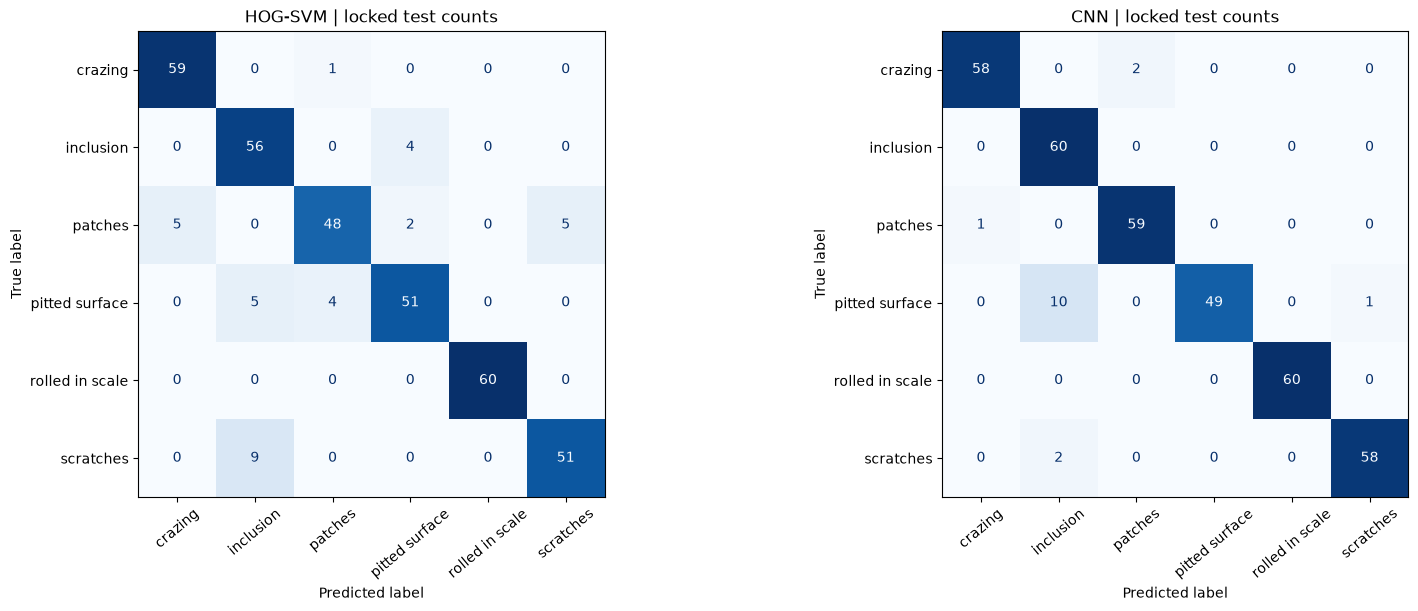

,model,class,precision,recall,f1-score,support
0,HOG-SVM,crazing,0.921875,0.983333,0.951613,60.0
1,HOG-SVM,inclusion,0.800000,0.933333,0.861538,60.0
2,HOG-SVM,patches,0.905660,0.800000,0.849558,60.0
3,HOG-SVM,pitted_surface,0.894737,0.850000,0.871795,60.0
4,HOG-SVM,rolled_in_scale,1.000000,1.000000,1.000000,60.0
5,HOG-SVM,scratches,0.910714,0.850000,0.879310,60.0
6,CNN,crazing,0.983051,0.966667,0.974790,60.0
7,CNN,inclusion,0.833333,1.000000,0.909091,60.0
8,CNN,patches,0.967213,0.983333,0.975207,60.0
9,CNN,pitted_surface,1.000000,0.816667,0.899083,60.0


The frozen CNN records accuracy **0.9556** and macro F1 **0.9555**, compared with **0.9028** and **0.9023** for HOG-SVM. The observed CNN minus SVM macro F1 difference is **+0.0532**. Each test class has 60 images, so macro recall and accuracy coincide here. Precision and F1 still respond differently to the allocation of false positives. These are results for this locked sample and these frozen implementations, not a universal comparison of handcrafted and learned representations.

For HOG-SVM, the lowest per-class recall is patches at 0.8000; ties are resolved alphabetically for this summary. The largest directed confusion is scratches predicted as inclusion (9 images; first class-order tie). A confusion identifies where review is needed, but it cannot establish whether texture ambiguity, labelling or acquisition conditions caused the error.

For CNN, the lowest per-class recall is pitted surface at 0.8167; ties are resolved alphabetically for this summary. The largest directed confusion is pitted surface predicted as inclusion (10 images; first class-order tie). A confusion identifies where review is needed, but it cannot establish whether texture ambiguity, labelling or acquisition conditions caused the error.

Clean evaluation mode: first authorised main evaluation


In [4]:
cache=RUN/'cache/clean_predictions.npz'; receipt_path=RUN/'cache/clean_receipt.json'
marker=RUN/'cache/clean_evaluation_started.json'
fresh=not cache.exists()
if fresh:
    with marker.open('x',encoding='utf-8') as handle:
        json.dump({'utc':datetime.now(timezone.utc).isoformat(),'protocol_sha256':protocol_hash,'status':'STARTED'},handle,indent=2)
    mode='first authorised main evaluation'
else:
    check('Clean receipt exists',receipt_path.is_file())
    receipt=readj(receipt_path)
    check('Clean cache integrity',sha(cache)==receipt['cache_sha256'] and receipt['protocol_sha256']==protocol_hash)
    mode='verified saved predictions replay; no main model evaluation'
start=perf_counter()
raw=np.stack([decode(r,'test_analysis') for r in test.itertuples()])
decode_hash_seconds=perf_counter()-start
images=raw.astype(np.float32)/255.0
y=encode(test.class_name)
if fresh:
    clean_features=features(images)
    svm_pred=encode(svm.predict(clean_features)); logits=cnn_logits(images)
    probabilities=torch.softmax(torch.from_numpy(logits),dim=1).numpy()
    cnn_pred=logits.argmax(axis=1)
    check('Finite clean outputs',np.isfinite(logits).all() and np.isfinite(clean_features).all())
    with cache.with_suffix('.tmp').open('wb') as handle:
        np.savez_compressed(handle,paths=test.path.to_numpy(dtype=str),truth=y,svm_pred=svm_pred,cnn_pred=cnn_pred,logits=logits,probabilities=probabilities)
    cache.with_suffix('.tmp').replace(cache)
    writej(receipt_path,{'status':'COMMITTED','utc':datetime.now(timezone.utc).isoformat(),'cache_sha256':sha(cache),'protocol_sha256':protocol_hash,'n':360,'main_evaluation_count':1})
with np.load(cache,allow_pickle=False) as saved:
    check('Identical ordered locked test paths',np.array_equal(saved['paths'],test.path.to_numpy(dtype=str)))
    check('Identical test labels',np.array_equal(saved['truth'],y))
    svm_pred=saved['svm_pred'].copy(); cnn_pred=saved['cnn_pred'].copy()
    probabilities=saved['probabilities'].copy(); logits=saved['logits'].copy()
check('Exactly 360 predictions for each model',svm_pred.shape==cnn_pred.shape==(360,) and np.isin(svm_pred,LABELS).all() and np.isin(cnn_pred,LABELS).all())
check('CNN class and score consistency',np.array_equal(cnn_pred,logits.argmax(1)) and np.allclose(probabilities.sum(1),1))
pd.DataFrame(access).to_csv(RUN/'reproducibility/image_decode_log.csv',index=False)
predictions=test[['path','class_name','sha256']].copy()
predictions['svm_predicted']=[CLASSES[i] for i in svm_pred]
predictions['cnn_predicted']=[CLASSES[i] for i in cnn_pred]
predictions['svm_correct']=svm_pred==y; predictions['cnn_correct']=cnn_pred==y
predictions['cnn_max_softmax']=probabilities.max(1)
for i,c in enumerate(CLASSES): predictions['cnn_softmax_'+c]=probabilities[:,i]
table(predictions,'clean_predictions',show=False)
clean=pd.DataFrame([{'model':name,**metrics(y,p)} for name,p in [('HOG-SVM',svm_pred),('CNN',cnn_pred)]]).set_index('model')
table(clean,'clean_metrics',index=True)
per_class=[]
fig,axes=plt.subplots(1,2,figsize=(16,6),layout='constrained')
for ax,(name,p) in zip(axes,[('HOG-SVM',svm_pred),('CNN',cnn_pred)]):
    report=classification_report(y,p,labels=LABELS,target_names=CLASSES,output_dict=True,zero_division=0)
    for c in CLASSES: per_class.append({'model':name,'class':c,**report[c]})
    cm=confusion_matrix(y,p,labels=LABELS)
    table(pd.DataFrame(cm,index=CLASSES,columns=CLASSES),name.lower()+'_confusion_counts',show=False,index=True)
    table(pd.DataFrame(cm/cm.sum(1,keepdims=True),index=CLASSES,columns=CLASSES),name.lower()+'_confusion_row_proportions',show=False,index=True)
    ConfusionMatrixDisplay(cm,display_labels=[c.replace('_',' ') for c in CLASSES]).plot(ax=ax,cmap='Blues',colorbar=False,xticks_rotation=40)
    ax.set_title(name+' | locked test counts')
figure(fig,'clean_confusion_matrices')
per_class=pd.DataFrame(per_class); table(per_class,'per_class_metrics')
interpret(f"The frozen CNN records accuracy **{clean.loc['CNN','accuracy']:.4f}** and macro F1 **{clean.loc['CNN','f1_macro']:.4f}**, compared with **{clean.loc['HOG-SVM','accuracy']:.4f}** and **{clean.loc['HOG-SVM','f1_macro']:.4f}** for HOG-SVM. The observed CNN minus SVM macro F1 difference is **{clean.loc['CNN','f1_macro']-clean.loc['HOG-SVM','f1_macro']:+.4f}**. Each test class has 60 images, so macro recall and accuracy coincide here. Precision and F1 still respond differently to the allocation of false positives. These are results for this locked sample and these frozen implementations, not a universal comparison of handcrafted and learned representations.")
for name,p in [('HOG-SVM',svm_pred),('CNN',cnn_pred)]:
    subset=per_class.loc[per_class.model.eq(name)]; worst=subset.sort_values(['recall','class']).iloc[0]
    cm=confusion_matrix(y,p,labels=LABELS); np.fill_diagonal(cm,0)
    a,b=np.unravel_index(cm.argmax(),cm.shape)
    interpret(f"For {name}, the lowest per-class recall is {worst['class'].replace('_',' ')} at {worst['recall']:.4f}; ties are resolved alphabetically for this summary. The largest directed confusion is {CLASSES[a].replace('_',' ')} predicted as {CLASSES[b].replace('_',' ')} ({cm[a,b]} images; first class-order tie). A confusion identifies where review is needed, but it cannot establish whether texture ambiguity, labelling or acquisition conditions caused the error.")
print('Clean evaluation mode:',mode)

### Reading the clean comparison critically

The aggregate gain is not uniform across defect categories. CNN pitted-surface recall is 0.8167, compared with 0.8500 for HOG-SVM. The CNN confusion matrix records 10 pitted-surface images predicted as inclusion. Conversely, patches recall is 0.9833 for CNN versus 0.8000 for HOG-SVM. An application where confusing pitting with inclusion is particularly costly could judge this trade-off differently from macro F1. No cost weighting is invented or selected from these test results.

## 4. Paired disagreements and uncertainty

The two predictions are paired by image. Correctness overlap is more informative than two isolated accuracy values: it distinguishes shared failures from errors that differ between representations. The high-confidence error table uses the CNN's uncalibrated softmax score. The SVM was frozen with probability estimation disabled; its decision scores are not substituted for probabilities and no calibration is fitted after test access. See the [SVC documentation](https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html).

A predeclared paired stratified bootstrap resamples image indices within each true class, applying each resample to both models. Percentile intervals describe uncertainty conditional on this sample, class balance and frozen fitted models. Unknown acquisition dependence, model-selection variability and domain shift are not captured. The intervals are exploratory, without multiplicity adjustment or a universal superiority claim.

In [5]:
categories=['both_correct','svm_correct_cnn_wrong','cnn_correct_svm_wrong','both_wrong']
predictions['category']=np.select([
    (svm_pred==y)&(cnn_pred==y),(svm_pred==y)&(cnn_pred!=y),(svm_pred!=y)&(cnn_pred==y)],categories[:3],default='both_wrong')
counts=predictions.category.value_counts().reindex(categories,fill_value=0)
table(counts.rename_axis('category').reset_index(name='n'),'disagreement_counts')
for category in categories:
    table(predictions.loc[predictions.category.eq(category)],'disagreements_'+category,show=False)
high_errors=predictions.loc[(~predictions.cnn_correct)&predictions.cnn_max_softmax.ge(0.90)].sort_values(['cnn_max_softmax','path'],ascending=[False,True])
table(high_errors[['path','class_name','cnn_predicted','cnn_max_softmax','svm_predicted']],'cnn_high_confidence_errors')
rng=np.random.default_rng(42); bootstrap=[]
groups=[np.flatnonzero(y==i) for i in LABELS]
for repeat in range(2000):
    idx=np.concatenate([rng.choice(g,len(g),replace=True) for g in groups])
    a=metrics(y[idx],svm_pred[idx]); b=metrics(y[idx],cnn_pred[idx])
    bootstrap.append({'repeat':repeat,'delta_accuracy':b['accuracy']-a['accuracy'],'delta_macro_f1':b['f1_macro']-a['f1_macro']})
boot=pd.DataFrame(bootstrap); table(boot,'paired_bootstrap_draws',show=False)
interval=pd.DataFrame([{'metric':key,'estimate':clean.loc['CNN',metric]-clean.loc['HOG-SVM',metric],
 'lower_95':boot[key].quantile(.025),'upper_95':boot[key].quantile(.975)} for key,metric in [('delta_accuracy','accuracy'),('delta_macro_f1','f1_macro')]])
table(interval,'paired_bootstrap_intervals')
interpret(f"HOG-SVM alone is correct on **{counts['svm_correct_cnn_wrong']}** images, CNN alone on **{counts['cnn_correct_svm_wrong']}**, and both are wrong on **{counts['both_wrong']}**. Both are correct on **{counts['both_correct']}**. There are **{len(high_errors)} CNN errors with maximum softmax at least 0.90**. Such errors matter for automation bias: a confident display can still accompany a wrong class. Error complementarity motivates future investigation but is not evidence for an ensemble selected on this test set.")
ci=interval.loc[interval.metric.eq('delta_macro_f1')].iloc[0]
interpret(f"The image-level paired bootstrap 95% percentile interval for the CNN minus SVM macro F1 difference is **[{ci.lower_95:+.4f}, {ci.upper_95:+.4f}]**. Interpret this alongside the observed paired error counts. It does not include uncertainty from factories, production batches, repeated training or class prevalence.")

,category,n
0,both_correct,315
1,svm_correct_cnn_wrong,10
2,cnn_correct_svm_wrong,29
3,both_wrong,6


,path,class_name,cnn_predicted,cnn_max_softmax,svm_predicted


,metric,estimate,lower_95,upper_95
0,delta_accuracy,0.052778,0.019444,0.086111
1,delta_macro_f1,0.053191,0.019844,0.086526


HOG-SVM alone is correct on **10** images, CNN alone on **29**, and both are wrong on **6**. Both are correct on **315**. There are **0 CNN errors with maximum softmax at least 0.90**. Such errors matter for automation bias: a confident display can still accompany a wrong class. Error complementarity motivates future investigation but is not evidence for an ensemble selected on this test set.

The image-level paired bootstrap 95% percentile interval for the CNN minus SVM macro F1 difference is **[+0.0198, +0.0865]**. Interpret this alongside the observed paired error counts. It does not include uncertainty from factories, production batches, repeated training or class prevalence.

## 5. CNN Grad-CAM and HOG representation visualisation

[Captum LayerGradCam](https://captum.ai/api/layer.html) attributes a selected output to a convolutional layer. Here the target is a class **logit**, the layer is `conv3`, and `relu_attributions=True` keeps positive contributions. Maps are 25 by 25 before bilinear upsampling to 200 by 200. Predicted-class and true-class targets are shown side by side, including when they coincide. Each panel is independently scaled to [0,1] for display; raw maps and extrema are saved, and colour intensity cannot be compared between panels. An all-zero positive map remains zero.

The selection rule deliberately spans error types rather than choosing visually persuasive maps. It is illustrative and outcome-conditioned, not representative sampling. No localisation masks, expert annotation, randomisation checks or causal intervention validate these explanations. Upsampling creates no new spatial evidence, and a plausible hotspot is not proof that the network recognises a physical defect. The original [Grad-CAM paper](https://arxiv.org/abs/1610.02391) describes the method; the limits of this implementation remain material.

HOG panels show local gradient structure used by the descriptor. They are **representation visualisations, not prediction attribution** for the nonlinear SVM. Incomplete border cells are omitted by the frozen descriptor.

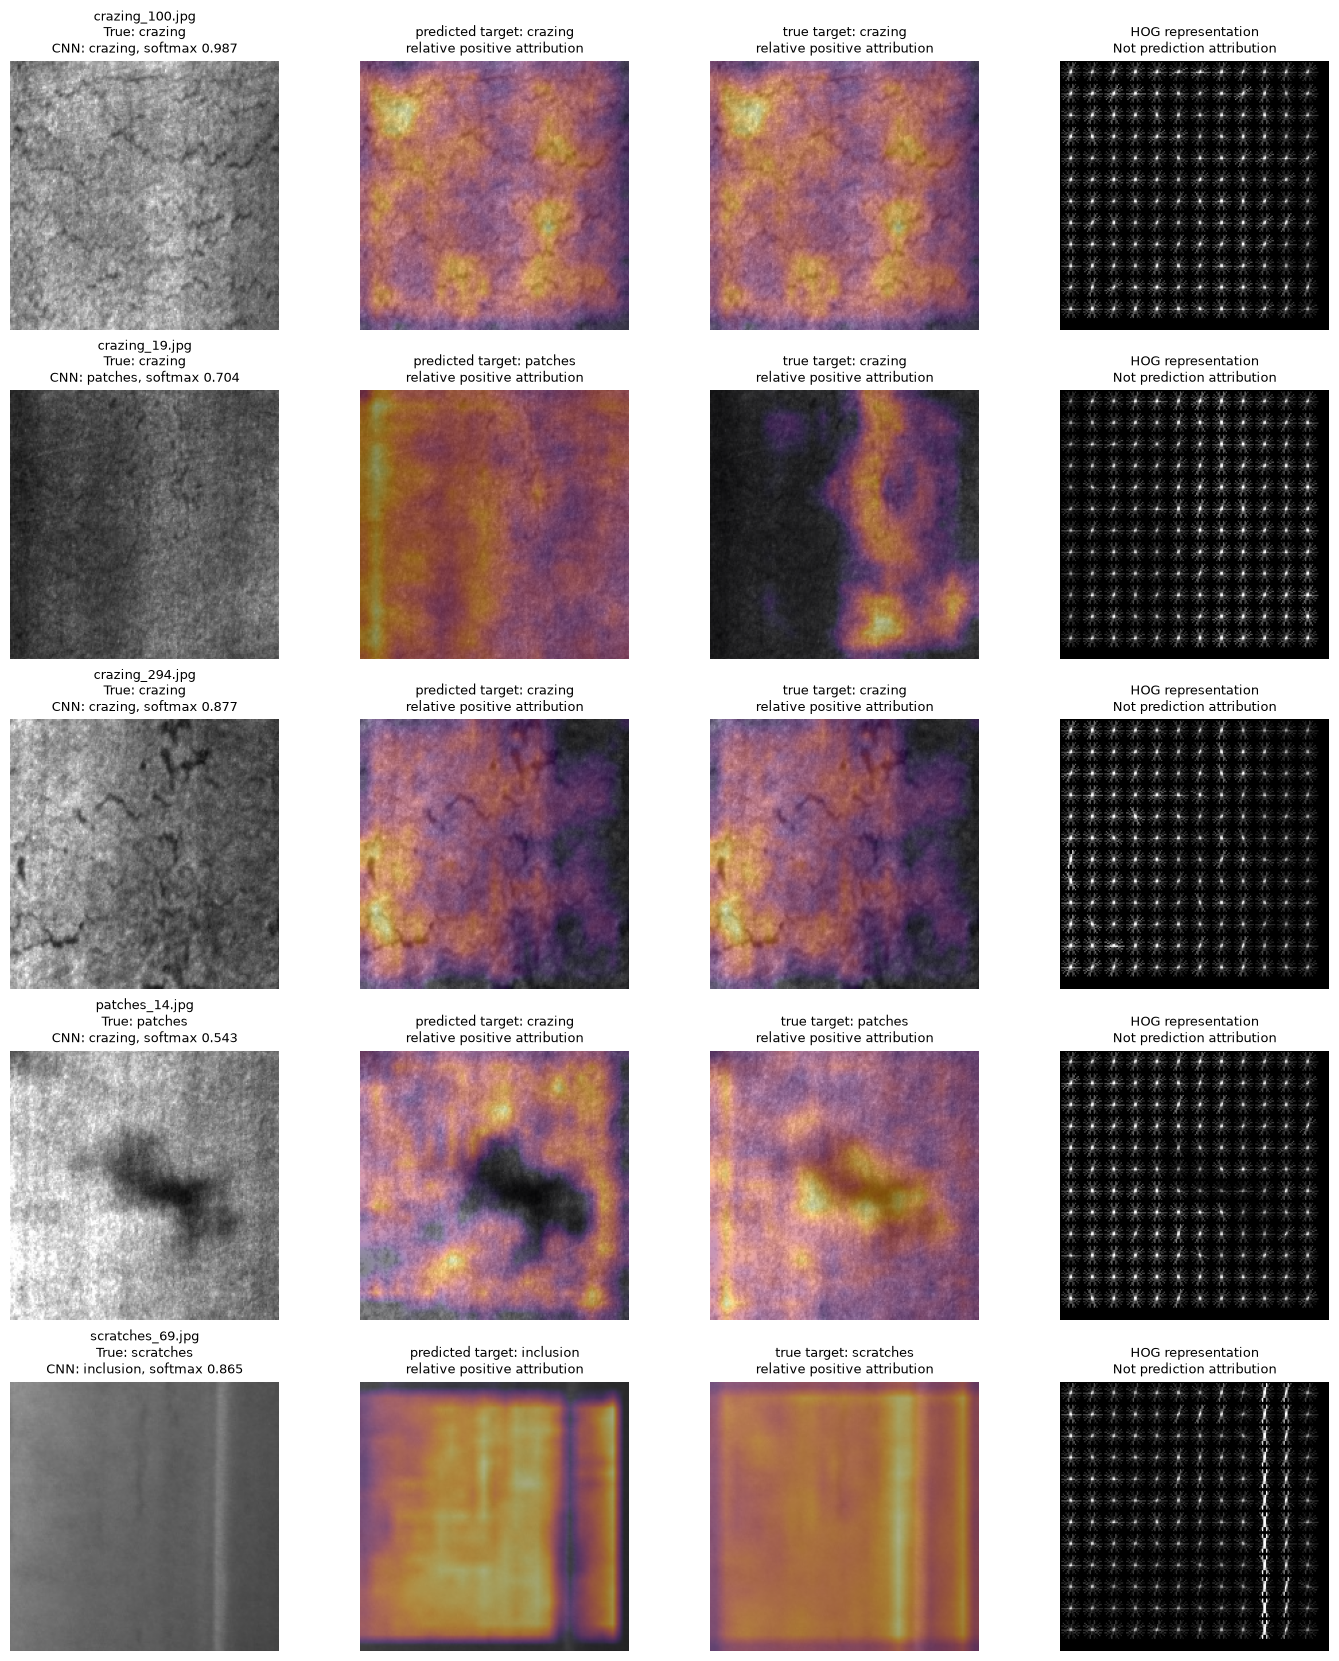

,index,path,category,selection_reason,target_role,target_class,native_min,native_max,native_positive_fraction,native_shape
0,0,data/NEU-CLS/train/train/images/crazing_100.jpg,both_correct,first path: both_correct; first CNN-correct path,predicted,crazing,0.000942,0.017161,1.0000,25x25
1,0,data/NEU-CLS/train/train/images/crazing_100.jpg,both_correct,first path: both_correct; first CNN-correct path,true,crazing,0.000942,0.017161,1.0000,25x25
2,22,data/NEU-CLS/train/train/images/crazing_19.jpg,svm_correct_cnn_wrong,first path: svm_correct_cnn_wrong,predicted,patches,0.004734,0.018593,1.0000,25x25
3,22,data/NEU-CLS/train/train/images/crazing_19.jpg,svm_correct_cnn_wrong,first path: svm_correct_cnn_wrong,true,crazing,0.000000,0.013665,0.5632,25x25
4,43,data/NEU-CLS/train/train/images/crazing_294.jpg,cnn_correct_svm_wrong,first path: cnn_correct_svm_wrong,predicted,crazing,0.000000,0.016416,0.9296,25x25
5,43,data/NEU-CLS/train/train/images/crazing_294.jpg,cnn_correct_svm_wrong,first path: cnn_correct_svm_wrong,true,crazing,0.000000,0.016416,0.9296,25x25
6,126,data/NEU-CLS/train/train/images/patches_14.jpg,both_wrong,first path: both_wrong,predicted,crazing,0.000000,0.012087,0.9056,25x25
7,126,data/NEU-CLS/train/train/images/patches_14.jpg,both_wrong,first path: both_wrong,true,patches,0.003655,0.021491,1.0000,25x25
8,348,data/NEU-CLS/train/train/images/scratches_69.jpg,both_wrong,highest-softmax CNN error,predicted,inclusion,0.000000,0.004134,0.9040,25x25
9,348,data/NEU-CLS/train/train/images/scratches_69.jpg,both_wrong,highest-softmax CNN error,true,scratches,0.001797,0.007846,1.0000,25x25


The selection rule yields **5 unique images**, with **2 CNN-correct** and **3 CNN-incorrect** cases. Of the 10 target maps, **0** have no positive attribution. Predicted and true targets contextualise the same image; visual differences suggest questions for expert review rather than establishing why the model failed. Spatially broad responses can reflect distributed texture evidence or background sensitivity, which this analysis cannot separate.

In [6]:
selected=[]; selection_reasons={}
def add_case(i,reason):
    i=int(i)
    if i not in selected: selected.append(i); selection_reasons[i]=[]
    selection_reasons[i].append(reason)
for category in categories:
    ids=np.flatnonzero(predictions.category.eq(category).to_numpy())
    if len(ids): add_case(ids[0],'first path: '+category)
errors=predictions.loc[~predictions.cnn_correct].sort_values(['cnn_max_softmax','path'],ascending=[False,True])
if len(errors): add_case(errors.index[0],'highest-softmax CNN error')
correct_ids=np.flatnonzero(cnn_pred==y)
if len(correct_ids): add_case(correct_ids[0],'first CNN-correct path')
fig,axes=plt.subplots(len(selected),4,figsize=(14,3.3*len(selected)),squeeze=False,layout='constrained')
cam_rows=[]
for row,i in enumerate(selected):
    axes[row,0].imshow(raw[i],cmap='gray',vmin=0,vmax=255)
    axes[row,0].set_title(f"{Path(test.path.iloc[i]).name}\nTrue: {CLASSES[y[i]]}\nCNN: {CLASSES[cnn_pred[i]]}, softmax {probabilities[i].max():.3f}",fontsize=9)
    for col,(target_name,target) in enumerate([('predicted',cnn_pred[i]),('true',y[i])],start=1):
        x=tensor(images[i:i+1]).requires_grad_(True)
        attr=gc.attribute(x,target=int(target),relu_attributions=True)
        check(f'Finite Grad-CAM {i} {target_name}',torch.isfinite(attr).all().item())
        native=attr.detach().numpy()[0,0]
        up=LayerAttribution.interpolate(attr,(200,200),interpolate_mode='bilinear').detach().numpy()[0,0]
        scaled=up/up.max() if up.max()>0 else np.zeros_like(up)
        np.savez_compressed(RUN/'cache'/f'gradcam_{i}_{target_name}.npz',native=native,upsampled=up)
        axes[row,col].imshow(raw[i],cmap='gray',vmin=0,vmax=255)
        axes[row,col].imshow(scaled,cmap='inferno',alpha=.48,vmin=0,vmax=1)
        axes[row,col].set_title(target_name+' target: '+CLASSES[target]+'\nrelative positive attribution',fontsize=9)
        cam_rows.append({'index':i,'path':test.path.iloc[i],'category':predictions.category.iloc[i],
            'selection_reason':'; '.join(selection_reasons[i]),'target_role':target_name,'target_class':CLASSES[target],
            'native_min':float(native.min()),'native_max':float(native.max()),'native_positive_fraction':float((native>0).mean()),'native_shape':'25x25'})
    _,visual=hog(images[i],visualize=True,**HOG)
    axes[row,3].imshow(visual,cmap='gray',vmin=0,vmax=max(float(np.percentile(visual,99.5)),1e-12))
    axes[row,3].set_title('HOG representation\nNot prediction attribution',fontsize=9)
    for ax in axes[row]: ax.axis('off')
figure(fig,'gradcam_and_hog_cases')
cam_table=pd.DataFrame(cam_rows); table(cam_table,'gradcam_cases')
interpret(f"The selection rule yields **{len(selected)} unique images**, with **{int((cnn_pred[selected]==y[selected]).sum())} CNN-correct** and **{int((cnn_pred[selected]!=y[selected]).sum())} CNN-incorrect** cases. Of the {len(cam_table)} target maps, **{int(cam_table.native_max.eq(0).sum())}** have no positive attribution. Predicted and true targets contextualise the same image; visual differences suggest questions for expert review rather than establishing why the model failed. Spatially broad responses can reflect distributed texture evidence or background sensitivity, which this analysis cannot separate.")

### Interpretation of the displayed cases

In `crazing_100.jpg`, the predicted and true targets coincide and the maps are identical, as expected. Stronger responses occur in several regions of the textured image; the map does not trace a validated defect boundary. For `crazing_19.jpg`, the incorrect patches target has a broad positive response, while the crazing target is more concentrated on the right. This difference is target-dependent evidence, not proof that a particular feature caused the error.

For `patches_14.jpg`, the true patches map includes the prominent central dark region, while the predicted crazing map places relatively greater weight around it. The image is nevertheless misclassified. A visually plausible true-class map therefore does not imply that the corresponding class wins the model's decision. In `scratches_69.jpg`, both targets have broad responses and different emphasis near the vertical structure. The highest-softmax CNN error has a score of approximately 0.865, below the predeclared 0.90 threshold. There are no errors meeting that threshold in this sample; this does not establish calibration or justify a production confidence threshold.

Three of the five selected images are crazing examples because class-prefixed filenames affect the first-path rule. The rule avoids discretionary visual cherry-picking but sacrifices class coverage. These cases cannot characterise explanations across all six classes. HOG panels show gradient structure only; their appearance cannot explain the SVM's individual decisions.

## 6. Diagnostic subgroup analysis

The thresholds are fixed from development and applied unchanged to clean test properties. Reported macro F1 always averages the same six classes, including zero for undefined class scores, and the class counts accompany every subgroup. Small or missing classes can depress this metric and make comparisons unstable. Within-class recalls help distinguish composition effects from condition effects but do not remove confounding. Multiple overlapping exploratory comparisons are not causal tests or demographic fairness evidence.

,property,bin,n,model,accuracy,precision_macro,recall_macro,f1_macro
0,brightness,low,121,HOG-SVM,0.917355,0.930235,0.898490,0.904302
1,brightness,low,121,CNN,0.958678,0.965278,0.932090,0.944293
2,brightness,middle,118,HOG-SVM,0.932203,0.934704,0.901929,0.910126
3,brightness,middle,118,CNN,0.940678,0.951389,0.879085,0.883161
4,brightness,high,121,HOG-SVM,0.859504,0.819181,0.836310,0.811915
5,brightness,high,121,CNN,0.966942,0.932479,0.982738,0.954153
6,contrast,low,120,HOG-SVM,0.933333,0.633658,0.602793,0.614296
7,contrast,low,120,CNN,0.966667,0.649832,0.613636,0.628013
8,contrast,middle,120,HOG-SVM,0.908333,0.833889,0.899380,0.853224
9,contrast,middle,120,CNN,0.933333,0.867521,0.953597,0.891846


,property,bin,n,crazing,inclusion,patches,pitted_surface,rolled_in_scale,scratches
0,brightness,low,121,10,33,14,11,14,39
1,brightness,middle,118,25,17,11,9,39,17
2,brightness,high,121,25,10,35,40,7,4
3,contrast,low,120,0,51,0,11,36,22
4,contrast,middle,120,29,7,4,29,24,27
5,contrast,high,120,31,2,56,20,0,11
6,sharpness,low,121,0,60,0,20,0,41
7,sharpness,middle,118,0,0,11,40,48,19
8,sharpness,high,121,60,0,49,0,12,0


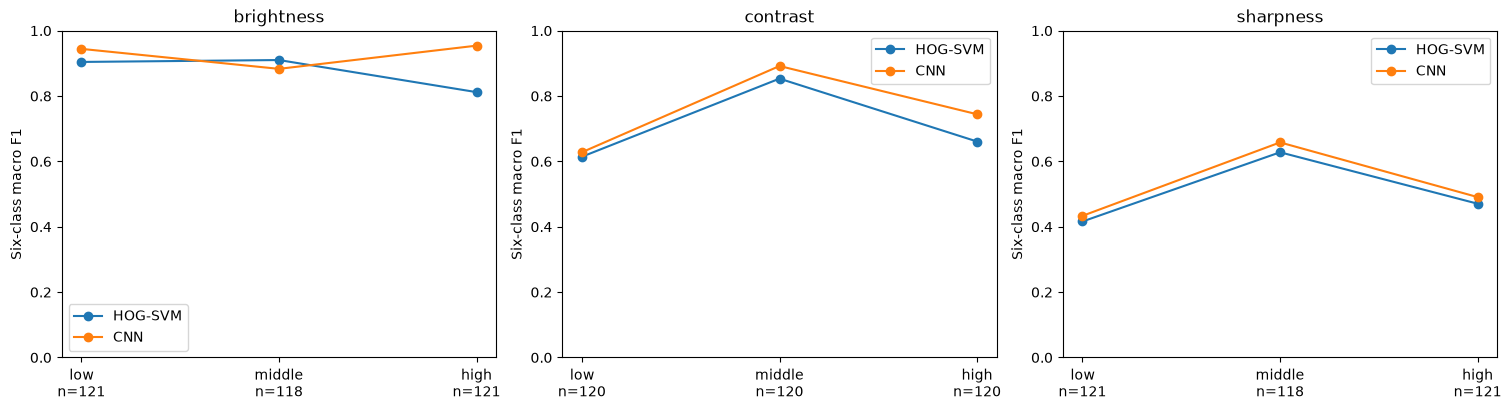

The lowest observed diagnostic subgroup macro F1 for HOG-SVM is **0.4162** in **sharpness, low** (n=121). This identifies an audit priority, not a causal effect of that property. The accompanying class counts and within-class recalls are necessary context; brightness, contrast and sharpness can describe the defect itself as well as the imaging setup.

The lowest observed diagnostic subgroup macro F1 for CNN is **0.4335** in **sharpness, low** (n=121). This identifies an audit priority, not a causal effect of that property. The accompanying class counts and within-class recalls are necessary context; brightness, contrast and sharpness can describe the defect itself as well as the imaging setup.

In [7]:
test_properties=pd.DataFrame([{'path':r.path,'class_name':r.class_name,**properties(raw[i])} for i,r in enumerate(test.itertuples())])
subgroups=[]; compositions=[]; class_recalls=[]
for prop,(q1,q2) in thresholds.items():
    bins=np.searchsorted([q1,q2],test_properties[prop].to_numpy(),side='left')
    test_properties[prop+'_bin']=np.array(['low','middle','high'])[bins]
    for b,label in enumerate(['low','middle','high']):
        idx=np.flatnonzero(bins==b)
        composition={'property':prop,'bin':label,'n':len(idx),**{c:int((y[idx]==k).sum()) for k,c in enumerate(CLASSES)}}
        compositions.append(composition)
        for name,p in [('HOG-SVM',svm_pred),('CNN',cnn_pred)]:
            if len(idx): subgroups.append({'property':prop,'bin':label,'n':len(idx),'model':name,**metrics(y[idx],p[idx])})
            for k,c in enumerate(CLASSES):
                ci=idx[y[idx]==k]
                class_recalls.append({'property':prop,'bin':label,'model':name,'class':c,'n':len(ci),'recall':float((p[ci]==k).mean()) if len(ci) else np.nan})
table(test_properties,'test_image_properties',show=False)
subgroups=pd.DataFrame(subgroups); table(subgroups,'diagnostic_subgroup_metrics')
table(pd.DataFrame(compositions),'diagnostic_subgroup_class_counts')
table(pd.DataFrame(class_recalls),'diagnostic_subgroup_class_recalls',show=False)
fig,axes=plt.subplots(1,3,figsize=(15,4),layout='constrained')
for ax,prop in zip(axes,thresholds):
    for name in ['HOG-SVM','CNN']:
        s=subgroups.loc[subgroups.property.eq(prop)&subgroups.model.eq(name)].set_index('bin').reindex(['low','middle','high'])
        ax.plot(range(3),s.f1_macro,marker='o',label=name)
    ns=pd.DataFrame(compositions).loc[lambda x:x.property.eq(prop)]
    ax.set_xticks(range(3),[f'{r.bin}\nn={r.n}' for r in ns.itertuples()])
    ax.set(title=prop,ylabel='Six-class macro F1',ylim=(0,1)); ax.legend()
figure(fig,'diagnostic_subgroups')
for name in ['HOG-SVM','CNN']:
    s=subgroups.loc[subgroups.model.eq(name)].sort_values(['f1_macro','property','bin']).iloc[0]
    interpret(f"The lowest observed diagnostic subgroup macro F1 for {name} is **{s.f1_macro:.4f}** in **{s.property}, {s.bin}** (n={s.n}). This identifies an audit priority, not a causal effect of that property. The accompanying class counts and within-class recalls are necessary context; brightness, contrast and sharpness can describe the defect itself as well as the imaging setup.")

### Class composition explains an apparent subgroup collapse

The low-sharpness group has 121 images: 60 inclusion, 20 pitted surface and 41 scratches, with no crazing, patches or rolled-in-scale examples. Its fixed-six-class macro F1 is 0.4335 for CNN and 0.4162 for HOG-SVM, while accuracy is 0.9091 and 0.8512, respectively. The three absent classes contribute zero to the declared macro calculation. Consequently, these low macro scores must not be presented as evidence of a comparable overall failure rate or as a causal effect of blur. Sharpness is strongly entangled with defect class in this collection. The class-specific recall table and subgroup sizes provide the more useful basis for targeted review.

## 7. Controlled robustness stress tests

Each predeclared condition transforms all 360 test images and preserves their labels. Models, scaler and CNN normalisation remain fixed. Delta means perturbed minus clean performance, with values on a 0 to 1 scale; multiplying by 100 gives percentage points. Negative values indicate degradation. Perturbed predictions and input array hashes are saved for every condition. These synthetic perturbations are stress tests, **not proof of performance under real factory shift**. No combined perturbations, severity sweep or new training is performed.

Completed fixed stress: blur_radius_0.5


Completed fixed stress: brightness_minus_10


Completed fixed stress: brightness_plus_10


Completed fixed stress: contrast_0.8


Completed fixed stress: noise_sigma_5


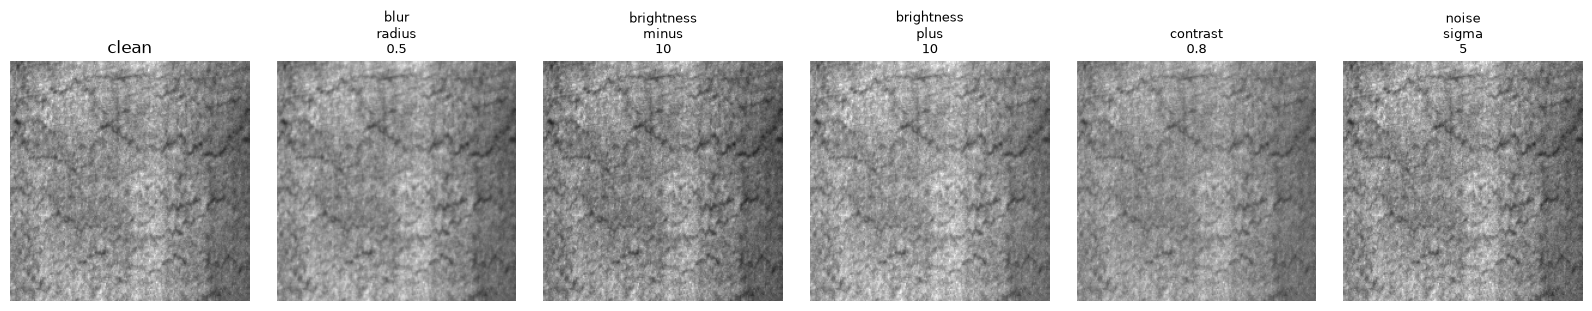

,condition,model,n,accuracy,precision_macro,recall_macro,f1_macro,delta_accuracy,delta_macro_f1
0,blur_radius_0.5,HOG-SVM,360,0.866667,0.871218,0.866667,0.866843,-0.036111,-0.035460
1,blur_radius_0.5,CNN,360,0.816667,0.853650,0.816667,0.793576,-0.138889,-0.161917
2,brightness_minus_10,HOG-SVM,360,0.900000,0.902532,0.900000,0.899338,-0.002778,-0.002965
3,brightness_minus_10,CNN,360,0.958333,0.962082,0.958333,0.958567,0.002778,0.003074
4,brightness_plus_10,HOG-SVM,360,0.883333,0.889515,0.883333,0.882939,-0.019444,-0.019363
5,brightness_plus_10,CNN,360,0.947222,0.954523,0.947222,0.945482,-0.008333,-0.010012
6,contrast_0.8,HOG-SVM,360,0.902778,0.905498,0.902778,0.902302,0.000000,0.000000
7,contrast_0.8,CNN,360,0.891667,0.916563,0.891667,0.891090,-0.063889,-0.064404
8,noise_sigma_5,HOG-SVM,360,0.569444,0.595459,0.569444,0.516830,-0.333333,-0.385472
9,noise_sigma_5,CNN,360,0.616667,0.646061,0.616667,0.544239,-0.338889,-0.411254


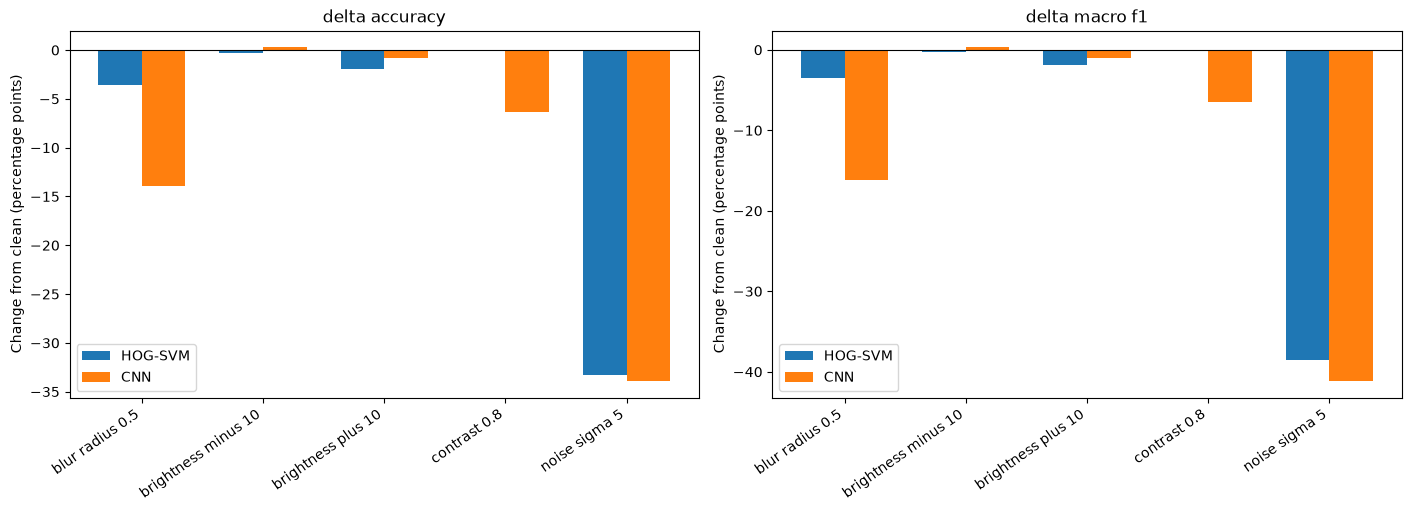

For HOG-SVM, the largest macro F1 degradation among the five declared stresses is **noise_sigma_5**: macro F1 **0.5168**, delta **-0.3855**, accuracy **0.5694**, delta **-0.3333**. These magnitudes depend on the chosen severities and one sample. An improvement under a perturbation would be descriptive, not permission to adopt that transform after test inspection.

For CNN, the largest macro F1 degradation among the five declared stresses is **noise_sigma_5**: macro F1 **0.5442**, delta **-0.4113**, accuracy **0.6167**, delta **-0.3389**. These magnitudes depend on the chosen severities and one sample. An improvement under a perturbation would be descriptive, not permission to adopt that transform after test inspection.

In [8]:
def perturb(name):
    if name=='blur_radius_0.5':
        out=np.stack([np.array(Image.fromarray(a).filter(ImageFilter.GaussianBlur(radius=.5)),dtype=np.float32)/255 for a in raw])
    elif name=='brightness_minus_10': out=images-10/255
    elif name=='brightness_plus_10': out=images+10/255
    elif name=='contrast_0.8':
        mean=images.mean(axis=(1,2),keepdims=True); out=mean+.8*(images-mean)
    elif name=='noise_sigma_5': out=images+np.random.default_rng(20260927).normal(0,5/255,images.shape).astype(np.float32)
    else: raise ValueError(name)
    return np.clip(out,0,1).astype(np.float32)
robust_rows=[]; stress_integrity=[]
example=int(np.flatnonzero(y==0)[0])
fig,axes=plt.subplots(1,6,figsize=(16,3),layout='constrained')
axes[0].imshow(images[example],cmap='gray',vmin=0,vmax=1); axes[0].set_title('clean')
for col,condition in enumerate(CONDITIONS,start=1):
    arr=perturb(condition)
    arr_hash=hashlib.sha256(arr.tobytes()).hexdigest()
    stress_path=RUN/'cache'/f'stress_{condition}.npz'; stress_receipt=stress_path.with_suffix('.json')
    if stress_path.exists():
        receipt=readj(stress_receipt)
        check('Stress cache '+condition,receipt['sha256']==sha(stress_path) and receipt['input_array_sha256']==arr_hash and receipt['protocol_sha256']==protocol_hash)
        with np.load(stress_path,allow_pickle=False) as s:
            check('Stress paths '+condition,np.array_equal(s['paths'],test.path.to_numpy(dtype=str)))
            sp=s['svm_pred']; cp=s['cnn_pred']
    else:
        sp=encode(svm.predict(features(arr))); cp=cnn_logits(arr).argmax(1)
        np.savez_compressed(stress_path,paths=test.path.to_numpy(dtype=str),svm_pred=sp,cnn_pred=cp)
        writej(stress_receipt,{'sha256':sha(stress_path),'input_array_sha256':arr_hash,'protocol_sha256':protocol_hash})
    check('Stress complete '+condition,sp.shape==cp.shape==(360,))
    stress_integrity.append({'condition':condition,'input_array_sha256':arr_hash,'prediction_sha256':sha(stress_path),'n':360})
    table(pd.DataFrame({'path':test.path,'true_class':test.class_name,'svm_predicted':[CLASSES[i] for i in sp],'cnn_predicted':[CLASSES[i] for i in cp]}),'stress_predictions_'+condition,show=False)
    for name,p in [('HOG-SVM',sp),('CNN',cp)]:
        m=metrics(y,p)
        robust_rows.append({'condition':condition,'model':name,'n':360,**m,'delta_accuracy':m['accuracy']-clean.loc[name,'accuracy'],'delta_macro_f1':m['f1_macro']-clean.loc[name,'f1_macro']})
    axes[col].imshow(arr[example],cmap='gray',vmin=0,vmax=1); axes[col].set_title(condition.replace('_','\n'),fontsize=9)
    print('Completed fixed stress:',condition,flush=True)
for ax in axes: ax.axis('off')
figure(fig,'stress_examples')
robust=pd.DataFrame(robust_rows); table(robust,'robustness_metrics')
writej(RUN/'reproducibility/stress_integrity.json',stress_integrity)
fig,axes=plt.subplots(1,2,figsize=(14,5),layout='constrained')
for ax,key in zip(axes,['delta_accuracy','delta_macro_f1']):
    for offset,name in [(-.18,'HOG-SVM'),(.18,'CNN')]:
        s=robust.loc[robust.model.eq(name)].set_index('condition').loc[CONDITIONS]
        ax.bar(np.arange(5)+offset,100*s[key],width=.36,label=name)
    ax.axhline(0,color='black',lw=.8); ax.set_xticks(range(5),[c.replace('_',' ') for c in CONDITIONS],rotation=35,ha='right')
    ax.set(ylabel='Change from clean (percentage points)',title=key.replace('_',' ')); ax.legend()
figure(fig,'robustness_deltas')
for name in ['HOG-SVM','CNN']:
    worst=robust.loc[robust.model.eq(name)].sort_values(['delta_macro_f1','condition']).iloc[0]
    interpret(f"For {name}, the largest macro F1 degradation among the five declared stresses is **{worst.condition}**: macro F1 **{worst.f1_macro:.4f}**, delta **{worst.delta_macro_f1:+.4f}**, accuracy **{worst.accuracy:.4f}**, delta **{worst.delta_accuracy:+.4f}**. These magnitudes depend on the chosen severities and one sample. An improvement under a perturbation would be descriptive, not permission to adopt that transform after test inspection.")

### The clean ranking does not hold under every stress

Under radius-0.5 blur, HOG-SVM macro F1 is 0.8668, exceeding CNN's 0.7936. Under contrast factor 0.8, HOG-SVM remains at 0.9023, while CNN falls to 0.8911. Stability under uniform contrast reduction is consistent with the normalised HOG representation, but this observation does not isolate the responsible mechanism.

CNN retains higher absolute macro F1 under the two brightness shifts and Gaussian noise. However, under noise its drop from clean performance is larger: -0.4113, versus -0.3855 for HOG-SVM. Neither model is robust to that declared noise condition in the sense of maintaining its clean performance. A numerically small pixel perturbation is not necessarily mild for model performance. These findings make camera focus, noise and contrast relevant priorities for a future factory-specific evaluation; they do not warrant retrofitting preprocessing using this test set.

## 8. Computation and deployment evidence

Both methods are benchmarked on this same CPU with four numerical-library threads where supported. Timing uses the first 32 development images, avoiding additional main test evaluation. Batch sizes 1 and 32 use three warm-ups and ten timed repetitions. Stages distinguish warm file read/decode, preprocessing, model-only inference and file-to-prediction end-to-end latency. CNN preprocessing includes scaling and frozen normalisation; SVM preprocessing includes scaling and HOG, with its fitted StandardScaler inside model inference. Each stage is measured independently, so its median need not sum to the end-to-end median. Throughput is batch size divided by median time, not sustained production throughput. The raw samples, library thread settings and hardware description are retained.

Warm filesystem caching, operating-system scheduling and sequential benchmarking limit precision. Timings exclude camera acquisition, queueing, network transfer, process startup and service orchestration. File size is serialisation size, not working memory or installed runtime size. No edge device, cloud API, GPU, energy use or production service is benchmarked.

In [9]:
bench_paths=[ROOT/p for p in dev.path.iloc[:32]]
def read_benchmark(paths):
    out=[]
    for p in paths:
        with Image.open(p) as im: out.append(np.array(im.convert('L'),dtype=np.uint8))
    return np.stack(out)
def svm_prepare(a): return features(a.astype(np.float32)/255)
def cnn_prepare(a): return tensor(a.astype(np.float32)/255)
@torch.inference_mode()
def forward(x): return cnn(x)
timing=[]
for batch in [1,32]:
    paths=bench_paths[:batch]; pixels=read_benchmark(paths)
    prepared={'HOG-SVM':svm_prepare(pixels),'CNN':cnn_prepare(pixels)}
    for name,prepare,infer in [('HOG-SVM',svm_prepare,svm.predict),('CNN',cnn_prepare,forward)]:
        operations={'file_read_decode':lambda:read_benchmark(paths),
            'preprocessing':lambda prepare=prepare:prepare(pixels),
            'model_only':lambda infer=infer,name=name:infer(prepared[name]),
            'end_to_end':lambda prepare=prepare,infer=infer:infer(prepare(read_benchmark(paths)))}
        for stage,operation in operations.items():
            for _ in range(3): operation()
            for repeat in range(10):
                start=perf_counter(); operation(); elapsed=perf_counter()-start
                timing.append({'model':name,'batch_size':batch,'stage':stage,'repeat':repeat,'seconds':elapsed})
timing=pd.DataFrame(timing); table(timing,'timing_raw',show=False)
summary=timing.groupby(['model','batch_size','stage']).seconds.agg(median_seconds='median',p95_seconds=lambda s:s.quantile(.95)).reset_index()
summary['median_ms']=1000*summary.median_seconds
summary['amortised_ms_per_image']=summary.median_ms/summary.batch_size
summary['images_per_second']=summary.batch_size/summary.median_seconds
table(summary,'timing_summary')
model_evidence=pd.DataFrame([
 {'model':'HOG-SVM','file_bytes':svm_path.stat().st_size,'cnn_parameter_count':None,'hog_dimensions':4356,'support_vectors':int(svm.named_steps['svm'].support_vectors_.shape[0])},
 {'model':'CNN','file_bytes':cnn_path.stat().st_size,'cnn_parameter_count':PARAMS,'hog_dimensions':None,'support_vectors':None}])
table(model_evidence,'model_size_and_complexity')
writej(RUN/'reproducibility/benchmark_scope.json',{'paths':[p.relative_to(ROOT).as_posix() for p in bench_paths],'source':'development only','raw_file_sha256':{p.relative_to(ROOT).as_posix():sha(p) for p in bench_paths},'warmups':3,'repeats':10,'threadpools':threadpool_info()})
for name in ['HOG-SVM','CNN']:
    single=summary.loc[summary.model.eq(name)&summary.batch_size.eq(1)&summary.stage.eq('end_to_end')].iloc[0]
    batch=summary.loc[summary.model.eq(name)&summary.batch_size.eq(32)&summary.stage.eq('end_to_end')].iloc[0]
    prep=summary.loc[summary.model.eq(name)&summary.batch_size.eq(1)&summary.stage.eq('preprocessing')].iloc[0]
    interpret(f"{name}: median warm file-to-prediction latency is **{single.median_ms:.3f} ms** for one image, with **{prep.median_ms:.3f} ms** independently measured preprocessing. Batch-32 end-to-end throughput is **{batch.images_per_second:.1f} images/s**. These local CPU measurements include preprocessing and decoding, but not an industrial acquisition pipeline.")
interpret(f"The frozen SVM file occupies **{svm_path.stat().st_size:,} bytes** and uses **4,356 HOG features**; the CNN checkpoint occupies **{cnn_path.stat().st_size:,} bytes** and has **{PARAMS:,} parameters**. The CNN checkpoint is smaller, but its framework and runtime footprint are not measured. Serialisation formats differ, so the ratio is a storage observation rather than a general memory-efficiency result. Edge deployment would need target-device timing, memory and thermal measurements; a cloud or inference API would add transport latency, availability, access control and commercial-data governance requirements.")

,model,batch_size,stage,median_seconds,p95_seconds,median_ms,amortised_ms_per_image,images_per_second
0,CNN,1,end_to_end,0.007036,0.007604,7.03600,7.036000,142.126208
1,CNN,1,file_read_decode,0.001663,0.002728,1.66270,1.662700,601.431396
2,CNN,1,model_only,0.003348,0.004213,3.34805,3.348050,298.681322
3,CNN,1,preprocessing,0.000205,0.000315,0.20490,0.204900,4880.429749
4,CNN,32,end_to_end,0.091254,0.098413,91.25400,2.851687,350.669560
5,CNN,32,file_read_decode,0.041068,0.046402,41.06815,1.283380,779.192634
6,CNN,32,model_only,0.038951,0.040610,38.95075,1.217211,821.550292
7,CNN,32,preprocessing,0.007987,0.008789,7.98715,0.249598,4006.435312
8,HOG-SVM,1,end_to_end,0.029352,0.036542,29.35150,29.351500,34.069809
9,HOG-SVM,1,file_read_decode,0.001280,0.001757,1.27955,1.279550,781.524741


,model,file_bytes,cnn_parameter_count,hog_dimensions,support_vectors
0,HOG-SVM,24503366,NaN,4356.0,1246.0
1,CNN,32865,6142.0,NaN,NaN


HOG-SVM: median warm file-to-prediction latency is **29.352 ms** for one image, with **13.389 ms** independently measured preprocessing. Batch-32 end-to-end throughput is **39.7 images/s**. These local CPU measurements include preprocessing and decoding, but not an industrial acquisition pipeline.

CNN: median warm file-to-prediction latency is **7.036 ms** for one image, with **0.205 ms** independently measured preprocessing. Batch-32 end-to-end throughput is **350.7 images/s**. These local CPU measurements include preprocessing and decoding, but not an industrial acquisition pipeline.

The frozen SVM file occupies **24,503,366 bytes** and uses **4,356 HOG features**; the CNN checkpoint occupies **32,865 bytes** and has **6,142 parameters**. The CNN checkpoint is smaller, but its framework and runtime footprint are not measured. Serialisation formats differ, so the ratio is a storage observation rather than a general memory-efficiency result. Edge deployment would need target-device timing, memory and thermal measurements; a cloud or inference API would add transport latency, availability, access control and commercial-data governance requirements.

## Reproducibility and reading order

All stage-05 outputs live in `outputs/experiments/05_comparison_xai_robustness/`. Read `reports/predeclared_protocol.json`, `reports/result.json`, `tables/clean_metrics.csv`, `tables/per_class_metrics.csv`, `tables/robustness_metrics.csv` and `reports/evidence_interpretation.md` first. Tables, figures, raw attribution maps, prediction caches, timing samples, environment versions, source hashes and image-access logs are retained. The executed notebook and HTML report are archived alongside the execution log after the notebook completes.

The clean receipt guards the one-time main evaluation. Do not delete it or the start marker to obtain a fresh run. If code or upstream sources change, the protocol checks stop reuse for review. Saved predictions permit metric verification without reopening model selection. Installation versions are recorded for reproducibility; checkpoint and source integrity must still be verified on any other machine.

Technical references: [Captum LayerGradCam](https://captum.ai/api/layer.html), [Grad-CAM original paper](https://arxiv.org/abs/1610.02391), [scikit-learn SVC](https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html). Dataset provenance, archive checksums and the remaining verification limits are documented in `data/NEU-CLS/Dataset-Information.txt`. Final consolidation should map the evidence to the original assignment brief available in the wider assignment context.

## 9. Ethics, monitoring and deployment implications

**Scope and consequences.** Every image in this benchmark is already assigned to a defect category. Neither model can establish that steel is defect-free, and accuracy here cannot be converted into defect detection sensitivity, false reject rates or safety assurance. Misclassification could send material to an unsuitable review or treatment route, increase scrap and rework, or delay recognition of a costly defect. The study does not quantify these operational costs or connect labels to engineering acceptance limits. A production system would require normal material, unknown defects and ambiguous examples, with domain experts defining the relevant consequences and acceptance criteria.

**Representativeness.** A balanced six-class archive does not reproduce factory prevalence or demonstrate robustness across cameras, steel grades, production lines, lighting or factories. Prior full-collection EDA, unverified equivalence to the original university archive and unknown acquisition groups further constrain generalisation. The present subgroup results identify audit priorities; the synthetic stresses probe selected image transformations. Neither resolves external validity. A later prospective evaluation should be separated by time and acquisition group, include multiple sites and retain factory metadata where lawful and appropriate.

**Human oversight and automation bias.** Confident errors and shared model failures make an unreviewed automatic disposition rule unjustified. A pilot should assist trained inspectors, preserve the image and model version, allow correction and escalation, and make uncertainty and scope visible. A Grad-CAM overlay is not an assurance badge. This notebook does not derive a rejection threshold, select an ensemble or optimise a cost policy from the test set. Any such policy needs development or newly collected validation data and an independently assessed operating point.

**Privacy and commercial sensitivity.** Steel crops may contain little personal information, but factory captures and metadata can reveal process settings, product identifiers, timestamps, client specifications or proprietary defects. Incidental people or identifiers in a wider acquisition stream require minimisation. Control access, retention and export; preserve traceability without unnecessary identifying data. Local inference may reduce transfer requirements but does not eliminate security duties. Cloud or API inference needs agreed data handling, encryption, access controls, service continuity and an assessment of network latency and commercial confidentiality. No legal compliance or safety certification is claimed here.

**Monitoring and change control.** During a supervised pilot, monitor camera settings, image-property distributions, missing/corrupt inputs, class prediction frequencies, review disagreement and delayed expert-labelled per-class errors. Input drift alone does not prove performance decline, while stable input summaries do not guarantee correctness. Define escalation rules with domain stakeholders, retain an audit trail, and review performance across equipment, shifts and grades. Retraining requires versioned data, documented label review, development-only model selection and a fresh independent evaluation. Retire this test set as a model-selection resource now that results are visible.

In [10]:
delta=float(clean.loc['CNN','f1_macro']-clean.loc['HOG-SVM','f1_macro'])
stress_wide=robust.pivot(index='condition',columns='model',values='f1_macro')
cnn_stress_higher=int((stress_wide.CNN>stress_wide['HOG-SVM']).sum())
conclusion=(f"## 10. Evidence-based comparative conclusion\n\n"
 f"**Observed facts.** On the identical 360-image locked test set, CNN macro F1 is {clean.loc['CNN','f1_macro']:.4f} and HOG-SVM macro F1 is {clean.loc['HOG-SVM','f1_macro']:.4f}, a CNN minus SVM difference of {delta:+.4f}. CNN accuracy is {clean.loc['CNN','accuracy']:.4f} and SVM accuracy is {clean.loc['HOG-SVM','accuracy']:.4f}. CNN has higher absolute macro F1 in {cnn_stress_higher} of the five predeclared stress conditions. Absolute stressed performance and loss relative to each model's clean baseline answer different questions and must be read together. The paired errors, per-class scores, diagnostic subgroups and timing tables qualify the headline comparison.\n\n"
 "**Limitations.** This is one frozen compact CNN and one fixed HOG descriptor with a selected RBF SVM, using different development search procedures. It does not isolate architecture from optimisation or representation choices. Image-level bootstrap uncertainty excludes unknown acquisition dependence and external shift. Selected attribution examples are not validated explanations; uncalibrated scores are not correctness probabilities. No normal class, independent factory cohort, deployment service or operational harm model is evaluated.\n\n"
 "**Deployment implication.** The measured comparison informs which frozen implementation merits further supervised assessment under the target factory's constraints. It does not establish universal superiority or production readiness. Preserve both models and this evaluation as evidence; use new, representative and independently assessed data for any subsequent model or operating-policy changes.")
interpret(conclusion)
check('Protocol unchanged',sha(protocol_path)==protocol_hash)
check('All source artefacts unchanged',all(sha(p)==source_hashes[k] for k,p in source_paths.items()))
check('CNN parameters and buffers unchanged',all(torch.equal(initial_state[k],v) for k,v in cnn.state_dict().items()))
check('Raw dataset hashes unchanged',all(sha(ROOT/r.path)==r.sha256 for r in manifest.itertuples()))
check('Single clean evaluation receipt',readj(receipt_path)['main_evaluation_count']==1 and sha(cache)==readj(receipt_path)['cache_sha256'])
check('All stress conditions reported',len(robust)==10 and robust.n.eq(360).all())
check('Metric bounds',clean.to_numpy().min()>=0 and clean.to_numpy().max()<=1)
check('Disagreement partition complete',int(counts.sum())==360)
check('Main predictions cover locked test exactly',len(predictions)==360 and predictions.path.is_unique and set(predictions.path)==set(test.path))
result={'status':'PASS','clean_evaluation_mode':mode,'main_evaluation_count':1,'test_images':360,
    'development_images':1439,'excluded_images':1,'protocol_sha256':protocol_hash,
    'clean_metrics':clean.reset_index().to_dict(orient='records'),'disagreement_counts':{k:int(v) for k,v in counts.items()},
    'high_softmax_errors':len(high_errors),'robustness':robust.to_dict(orient='records'),
    'source_hashes':source_hashes,'models_retuned':False}
writej(RUN/'reports/result.json',result)
writej(RUN/'reports/status.json',{'status':'PASS','utc':datetime.now(timezone.utc).isoformat(),'clean_predictions_sha256':sha(cache),'no_model_changes':True})
(RUN/'reports/evidence_interpretation.md').write_text('\n\n'.join(NARRATIVE),encoding='utf-8')
print('PASS: saved evidence and all integrity checks in',RUN)

## 10. Evidence-based comparative conclusion

**Observed facts.** On the identical 360-image locked test set, CNN macro F1 is 0.9555 and HOG-SVM macro F1 is 0.9023, a CNN minus SVM difference of +0.0532. CNN accuracy is 0.9556 and SVM accuracy is 0.9028. CNN has higher absolute macro F1 in 3 of the five predeclared stress conditions. Absolute stressed performance and loss relative to each model's clean baseline answer different questions and must be read together. The paired errors, per-class scores, diagnostic subgroups and timing tables qualify the headline comparison.

**Limitations.** This is one frozen compact CNN and one fixed HOG descriptor with a selected RBF SVM, using different development search procedures. It does not isolate architecture from optimisation or representation choices. Image-level bootstrap uncertainty excludes unknown acquisition dependence and external shift. Selected attribution examples are not validated explanations; uncalibrated scores are not correctness probabilities. No normal class, independent factory cohort, deployment service or operational harm model is evaluated.

**Deployment implication.** The measured comparison informs which frozen implementation merits further supervised assessment under the target factory's constraints. It does not establish universal superiority or production readiness. Preserve both models and this evaluation as evidence; use new, representative and independently assessed data for any subsequent model or operating-policy changes.

PASS: saved evidence and all integrity checks in C:\Scripts\industrial-defect-intelligence\outputs\experiments\05_comparison_xai_robustness
